In [34]:
from datasets import load_from_disk
import numpy as np
from transformers import (
	AutoModelForMaskedLM,
	AutoModelForSequenceClassification,
	AutoTokenizer,
	DataCollatorForLanguageModeling,
	Trainer,
	TrainingArguments,
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [35]:
seed = 42

large_dataset_path = "data/my_saved_dataset_large"
base_model_path = "data/my_saved_model"
output_model_path = "data/my_pretrained_model"
text_column = "text"

In [36]:
print("Loading large dataset...")
large_dataset = load_from_disk(large_dataset_path)
num_samples = 1000
large_dataset = large_dataset.shuffle(seed=seed).select(range(num_samples))


Loading large dataset...


In [37]:
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(base_model_path)

Loading tokenizer...


In [38]:
print("Loading base model...")
model = AutoModelForMaskedLM.from_pretrained(base_model_path).to("xpu")

Loading base model...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5776.96it/s]
[transformers] This checkpoint seem corrupted. The tied weights mapping for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are absent from the checkpoint, and we could not find another related tied weight for those keys
[transformers] BertForMaskedLM LOAD REPORT from: data/my_saved_model
Key                                        | Status     | 
-------------------------------------------+------------+-
classifier.bias                            | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.weight                          | UNEXPECTED | 
cls.predictions.transform.dense.bias       | MISSING    | 
cls.predictions.transform.LayerNorm.bias   | MISSING    | 
cls.predictions.bias                       | MISSING    | 
cls.predictions.transform.LayerNorm.weight | MISSING    | 
cls.pred

In [39]:
def tokenize_batch_large_dataset(batch):
	return tokenizer(
		batch[text_column]	
		, truncation=True,
		max_length=64,
	)

print("Tokenizing text column...")
tokenized_dataset = large_dataset.map(tokenize_batch_large_dataset, batched=True, remove_columns=large_dataset.column_names)


Tokenizing text column...


In [40]:
data_collator = DataCollatorForLanguageModeling(
	tokenizer=tokenizer,
	mlm=True,
	mlm_probability=0.15,
)

In [41]:
training_args = TrainingArguments(
	output_dir=output_model_path,
	per_device_train_batch_size=4,
	learning_rate=5e-5,
	num_train_epochs=1,
	logging_steps=50,
	save_steps=500,
	weight_decay=0.01,
	remove_unused_columns=False,
	report_to="none",
)

trainer = Trainer(
	model=model,
	args=training_args,
	train_dataset=tokenized_dataset,
	data_collator=data_collator
)

In [42]:
print("Starting training on unlabeled text...")
trainer.train()

print("Saving trained model and tokenizer...")
model.save_pretrained(output_model_path)
unlabaled_trained_model = model.to("xpu")
print(f"Finished unsupervised training. Saved to {output_model_path}")


Starting training on unlabeled text...


Step,Training Loss
50,8.142466
100,7.045345
150,6.416956
200,6.456886
250,6.286656


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.13s/it]


Saving trained model and tokenizer...


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.61it/s]

Finished unsupervised training. Saved to data/my_pretrained_model


In [43]:
small_dataset_path = "data/my_saved_dataset_small"
print("Loading small dataset...")
small_dataset = load_from_disk(small_dataset_path)
small_dataset = small_dataset.map(
	lambda example: {
		"split_stratify": f"{example['politics']}_{example['sentiment']}"
	}
)
small_dataset = small_dataset.class_encode_column("split_stratify")

Loading small dataset...


Casting to class labels: 100%|██████████| 3384/3384 [00:00<00:00, 40029.34 examples/s]


In [44]:
split_dataset = small_dataset.train_test_split(
	test_size=0.25,
	seed=seed,
	stratify_by_column="split_stratify"
)
train_dataset = split_dataset["train"]
test_dataset = split_dataset["test"]
print(f"Train size: {len(train_dataset)} | Test size: {len(test_dataset)}")

Train size: 2538 | Test size: 846


In [45]:
def tokenize_small_dataset_batch(batch):
	return tokenizer(
		batch[text_column],
		truncation=True,
		max_length=64,
		padding="max_length",
	)

print("Tokenizing small dataset...")
tokenized_train_dataset = train_dataset.map(tokenize_small_dataset_batch, batched=True, remove_columns=train_dataset.column_names)
tokenized_test_dataset = test_dataset.map(tokenize_small_dataset_batch, batched=True, remove_columns=test_dataset.column_names)


Tokenizing small dataset...


Map: 100%|██████████| 846/846 [00:00<00:00, 17671.49 examples/s]


In [46]:
training_args.output_dir = "data/my_finetuned_model"
small_trainer = Trainer(
	model=unlabaled_trained_model,
	args=training_args,
	train_dataset=tokenized_train_dataset,
	eval_dataset=tokenized_test_dataset,
    data_collator=data_collator
)

In [47]:
print("Starting supervised fine-tuning on small dataset...")
small_trainer.train()
print("Saving fine-tuned model and tokenizer...")
small_trainer.save_model("data/my_finetuned_model")
print("Finished supervised fine-tuning. Saved to data/my_finetuned_model")

Starting supervised fine-tuning on small dataset...


Step,Training Loss
50,6.115541
100,5.043769
150,4.723575
200,4.082091
250,4.010422
300,4.109160
350,3.708175
400,3.659587
450,3.686235
500,3.474606


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.41it/s]


Saving fine-tuned model and tokenizer...


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.33it/s]

Finished supervised fine-tuning. Saved to data/my_finetuned_model


In [48]:
eval_results = small_trainer.evaluate()
print(f"Evaluation results: {eval_results}")

Training Loss,Validation Loss,Step
3.273490,3.221049,635


Evaluation results: {'eval_loss': 3.221048593521118}


In [49]:
def tokenize_with_labels(batch):
    tokens = tokenizer(
        batch["text"],
        truncation=True,
        max_length=64,
        padding="max_length",
    )
    tokens["labels"] = batch["split_stratify"]
    return tokens

train_tokens = train_dataset.map(
	tokenize_with_labels,
	batched=True,
	remove_columns=train_dataset.column_names
)
test_tokens = test_dataset.map(
    tokenize_with_labels,
    batched=True,
    remove_columns=test_dataset.column_names
)

Map: 100%|██████████| 846/846 [00:00<00:00, 13552.80 examples/s]


In [50]:
clf_model = AutoModelForSequenceClassification.from_pretrained(
    output_model_path,
    num_labels=2,
    label2id={
        "left_positive": 0,
        "left_negative": 1,
        "right_positive": 2,
        "right_negative": 3
    },
    id2label={
        0: "left_positive",
        1: "left_negative",
        2: "right_positive",
        3: "right_negative"
    },
    ignore_mismatched_sizes=True,
)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5294.01it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: data/my_pretrained_model
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if 

In [51]:
cls_args = TrainingArguments(
	output_dir="tmp_eval",
	report_to="none",
	per_device_train_batch_size=8,
	per_device_eval_batch_size=8,
	learning_rate=5e-5,
	num_train_epochs=1,
)

# source for base code is https://medium.com/@rakeshrajpurohit/customized-evaluation-metrics-with-hugging-face-trainer-3ff00d936f99
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

pred_trainer = Trainer(
	model=clf_model,
	args=cls_args,
	train_dataset=train_tokens,
	eval_dataset=test_tokens,
    compute_metrics=compute_metrics
)
print("Starting training with custom metrics...")
pred_trainer.train()

Starting training with custom metrics...


Step,Training Loss


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.04s/it]


TrainOutput(global_step=318, training_loss=0.3522233543156078, metrics={'train_runtime': 71.0198, 'train_samples_per_second': 35.737, 'train_steps_per_second': 4.478, 'total_flos': 83473481235456.0, 'train_loss': 0.3522233543156078, 'epoch': 1.0})

Evaluation results:


Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
No log,0.197941,318,0.949173,0.949820,0.949173,0.949154


eval_loss: 0.1979
eval_accuracy: 0.9492
eval_precision: 0.9498
eval_recall: 0.9492
eval_f1: 0.9492


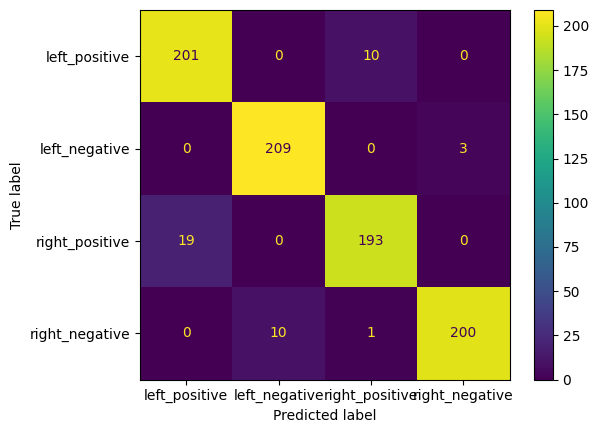

In [52]:
print("Evaluation results:")
results = pred_trainer.evaluate()
for metric_name, metric_value in results.items():
    print(f"{metric_name}: {metric_value:.4f}")


pred_output = pred_trainer.predict(test_tokens)
predictions = np.argmax(pred_output.predictions, axis=-1)
true_labels = np.array(test_tokens["labels"])
cm = confusion_matrix(true_labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['left_positive', 'left_negative', 'right_positive', 'right_negative'])
disp.plot()
plt.show()